# Construcción del modelo de vinos y exportación a PKL
**Gael Rodríguez Jiménez** — Analítica de datos, Tecmilenio · 24 de septiembre de 2026

Se entrena un `Pipeline` (StandardScaler + SVM lineal) con el dataset Wine y se guarda con **Joblib** en `modelo_wine.pkl`.

In [1]:
# Fija scikit-learn 1.9.0: un .pkl solo es fiable con la misma versión con que se guardó.
import sys, subprocess, importlib.metadata
version = "1.9.0"
if importlib.metadata.version("scikit-learn") != version:
    if "sklearn" in sys.modules:
        raise RuntimeError("Reinicia la sesión y ejecuta esta celda antes de importar sklearn.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "scikit-learn==" + version])
import sklearn
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.9.0


## Paso 1. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
plt.style.use("seaborn-v0_8-whitegrid")

## Paso 2. Cargar los datos
Wine viene incluido en scikit-learn: 178 muestras, 13 mediciones químicas, 3 clases.

In [3]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Paso 3. Asignar nombres a las clases

In [4]:
etiquetas = {0: "Cabernet", 1: "Merlot", 2: "Pinot Noir"}
clases = list(etiquetas.values())
df["tipo_vino"] = df["target"].map(etiquetas)
df[["alcohol", "proline", "target", "tipo_vino"]].head()

,alcohol,proline,target,tipo_vino
0,14.23,1065.0,0,Cabernet
1,13.20,1050.0,0,Cabernet
2,13.16,1185.0,0,Cabernet
3,14.37,1480.0,0,Cabernet
4,13.24,735.0,0,Cabernet


## Paso 4. Explorar los datos

In [5]:
print("Dimensiones:", df.shape)
print("Valores faltantes:", int(df.isna().sum().sum()))
conteos = df["tipo_vino"].value_counts().reindex(clases)
display(conteos.rename("registros").to_frame())
display(df.describe().T[["mean", "std", "min", "max"]].round(2))

Dimensiones: (178, 15)
Valores faltantes: 0


,registros
tipo_vino,
Cabernet,59
Merlot,71
Pinot Noir,48


,mean,std,min,max
alcohol,13.00,0.81,11.03,14.83
malic_acid,2.34,1.12,0.74,5.80
ash,2.37,0.27,1.36,3.23
alcalinity_of_ash,19.49,3.34,10.60,30.00
magnesium,99.74,14.28,70.00,162.00
total_phenols,2.30,0.63,0.98,3.88
flavanoids,2.03,1.00,0.34,5.08
nonflavanoid_phenols,0.36,0.12,0.13,0.66
proanthocyanins,1.59,0.57,0.41,3.58
color_intensity,5.06,2.32,1.28,13.00


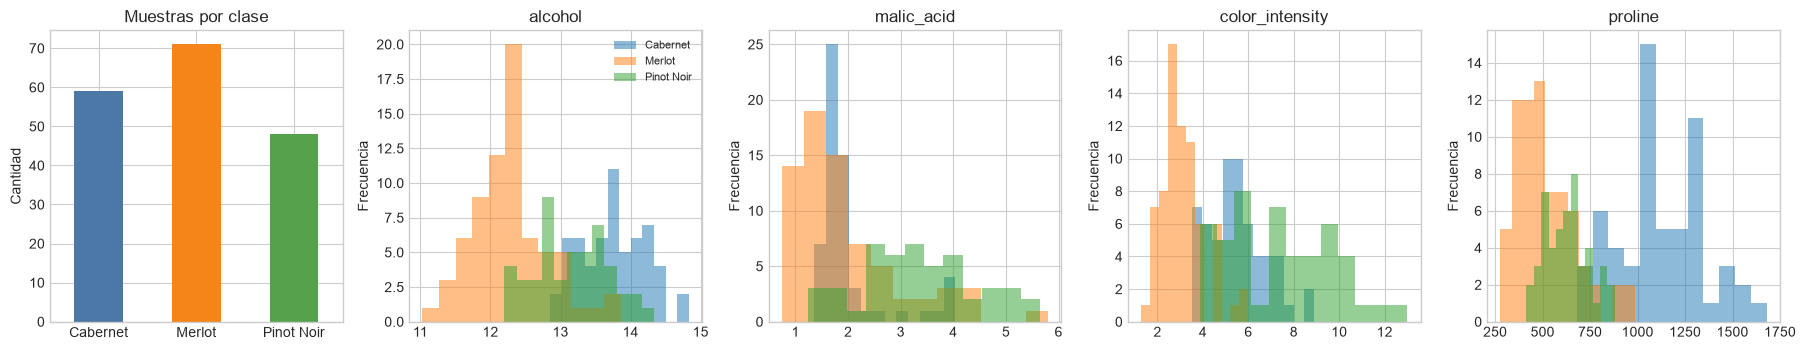

In [6]:
variables = ["alcohol", "malic_acid", "color_intensity", "proline"]
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6))
conteos.plot.bar(ax=axes[0], color=["#4c78a8", "#f58518", "#54a24b"], rot=0)
axes[0].set(title="Muestras por clase", xlabel="", ylabel="Cantidad")
for variable, ax in zip(variables, axes[1:]):
    for clase in clases:
        ax.hist(df.loc[df.tipo_vino == clase, variable], bins=12, alpha=0.5, label=clase)
    ax.set(title=variable, ylabel="Frecuencia")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

- **Faltantes:** no hay.
- **Balance:** las clases no son iguales (59 / 71 / 48), por eso se estratifica la partición.
- **Escalas:** `proline` va de 278 a 1680 y `malic_acid` de 0.74 a 5.8; el SVM es sensible a la escala, por eso se estandariza.

## Paso 5. Seleccionar las cuatro características
`target` no se usa como entrada porque es la respuesta.

In [7]:
X = df[variables]
y = df["tipo_vino"]
print("X:", X.shape, "| y:", y.shape)

X: (178, 4) | y: (178,)


## Paso 6. Separar entrenamiento y prueba (80 / 20, estratificado)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
pd.DataFrame({"Entrenamiento": y_train.value_counts(), "Prueba": y_test.value_counts()}).reindex(clases)

,Entrenamiento,Prueba
tipo_vino,,
Cabernet,47,12
Merlot,57,14
Pinot Noir,38,10


## Pasos 7 y 8. Construir y entrenar el Pipeline
El escalador aprende media y desviación **solo del entrenamiento**; el Pipeline garantiza que al predecir se aplique el mismo escalado.

In [9]:
modelo = Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="linear"))])
modelo.fit(X_train, y_train)
print("Clases aprendidas:", list(modelo.classes_))
modelo

Clases aprendidas: ['Cabernet', 'Merlot', 'Pinot Noir']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Cabernet','Merlot','Pinot Noir']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['alcohol','malic_acid','color_intensity','proline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Paso 9. Comparar predicciones con valores reales

In [10]:
y_pred = modelo.predict(X_test)
comparacion = pd.DataFrame({"Real": y_test, "Predicho": y_pred})
comparacion["Correcto"] = comparacion["Real"] == comparacion["Predicho"]
display(comparacion.head(10))
print("Errores:"); display(comparacion[~comparacion["Correcto"]])

,Real,Predicho,Correcto
10,Cabernet,Cabernet,True
134,Pinot Noir,Merlot,False
28,Cabernet,Cabernet,True
121,Merlot,Pinot Noir,False
62,Merlot,Merlot,True
51,Cabernet,Cabernet,True
7,Cabernet,Cabernet,True
66,Merlot,Merlot,True
129,Merlot,Merlot,True
166,Pinot Noir,Pinot Noir,True


Errores:


,Real,Predicho,Correcto
134,Pinot Noir,Merlot,False
121,Merlot,Pinot Noir,False
130,Pinot Noir,Merlot,False


## Paso 10. Evaluar el modelo

In [11]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
pd.DataFrame(classification_report(y_test, y_pred, labels=clases, output_dict=True)).T.round(3)

Accuracy: 0.9167


,precision,recall,f1-score,support
Cabernet,1.000,1.000,1.000,12.000
Merlot,0.867,0.929,0.897,14.000
Pinot Noir,0.889,0.800,0.842,10.000
accuracy,0.917,0.917,0.917,0.917
macro avg,0.919,0.910,0.913,36.000
weighted avg,0.917,0.917,0.916,36.000


## Paso 11. Matriz de confusión

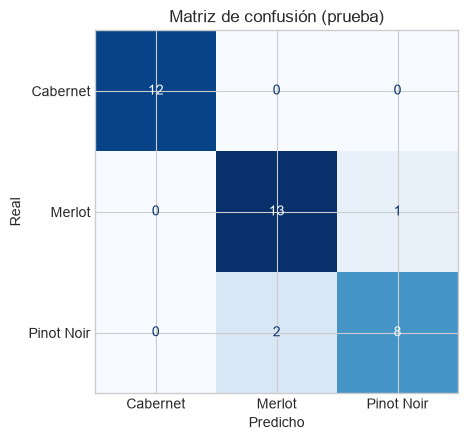

Aciertos: 33 | Errores: 3


In [12]:
cm = confusion_matrix(y_test, y_pred, labels=clases)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=clases).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set(title="Matriz de confusión (prueba)", xlabel="Predicho", ylabel="Real")
plt.tight_layout(); plt.show()
print("Aciertos:", int(np.trace(cm)), "| Errores:", int(cm.sum() - np.trace(cm)))

Cabernet se clasifica perfecto. La confusión está entre **Merlot y Pinot Noir** (2 Pinot Noir → Merlot, 1 Merlot → Pinot Noir).

## Paso 12. Predecir un vino nuevo

In [13]:
nuevo_vino = pd.DataFrame([[13.5, 1.8, 5.2, 1000]], columns=variables)
prediccion = modelo.predict(nuevo_vino)
print("Tipo de vino predicho:", prediccion[0])

Tipo de vino predicho:

 Cabernet


## Pasos 13 y 14. Guardar con Joblib, recuperar y comprobar
Se guarda el **Pipeline completo** para conservar el escalador y el clasificador juntos.

In [14]:
ruta_modelo = Path("modelo_wine.pkl")
joblib.dump(modelo, ruta_modelo)
print("Archivo generado:", ruta_modelo, "|", ruta_modelo.stat().st_size, "bytes")

modelo_recuperado = joblib.load(ruta_modelo)
assert np.array_equal(y_pred, modelo_recuperado.predict(X_test))
print("Antes de guardar:", prediccion[0], "| Después de cargar:", modelo_recuperado.predict(nuevo_vino)[0])
print("Verificación correcta: el modelo recuperado da las mismas predicciones.")

Archivo generado: modelo_wine.pkl | 4741 bytes
Antes de guardar: Cabernet | Después de cargar: Cabernet
Verificación correcta: el modelo recuperado da las mismas predicciones.


## Descargar el modelo (solo en Colab)

In [15]:
try:
    from google.colab import files
    files.download(str(ruta_modelo))
except ImportError:
    print("Fuera de Colab: el archivo quedó en", ruta_modelo.name)

Fuera de Colab: el archivo quedó en modelo_wine.pkl


## Reflexión final
Joblib permite separar el **entrenamiento** del **uso**: el modelo se entrena una vez, se guarda como `.pkl` y cualquier programa puede cargarlo y predecir sin repetir el ajuste. Guardar el Pipeline y no solo el SVM evita olvidar el escalado al predecir. Un `.pkl` solo debe cargarse si viene de una fuente confiable y con la misma versión de scikit-learn.